# Why are GiGPO state groups large?

**The optimization view retains every stored record, including `adjust_batch()`
copies.** This is the view used for actual GiGPO baseline means. A separate,
**deduplicated structural view** removes only copies of
`(traj_uid, phase, traj_idx, turn_idx)` to compare:

| Scheme | Key | Interpretation |
|---|---|---|
| A: Current GiGPO | `(uid, anchor_obs)` | Mixes attempts, trajectories, and repeated visits. |
| B: Attempt-aware | `(uid, anchor_obs, traj_idx)` | Removes cross-attempt mixing; preserves comparisons across parallel trajectories within an attempt. |
| C: Attempt + trajectory | `(uid, anchor_obs, traj_idx, traj_uid)` | Isolates repeated same-board visits within one trajectory/attempt. Diagnostic only, **not a proposed training method**. |

Eight trajectories times three attempts is 24 trajectory/attempt pairs, **not a
24-record limit**. Each pair can visit a board on multiple turns. With seven
turns per attempt, the theoretical maximum is 168 visits before batching copies.
This does not assume each trajectory uses all attempts or turns.

This notebook never changes training. Run cells in order; edit the paths and
inspection selections below. Requires pandas, matplotlib, and IPython.


In [3]:
import json
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "verl/trainer/config/ppo_trainer.yaml").is_file()), Path.cwd(),
)
DATA_DIR = REPO_ROOT / "diagnostics/gigpo_groups_capture/20260918T160830_869656757"
GROUPS_PATH = DATA_DIR / "step_000001_groups.jsonl"
SUMMARY_PATH = DATA_DIR / "step_000001_summary.json"
# New captures also write a complete play-record companion, discovered below.


## Load files and establish coverage

New captures include `step_XXXXXX_play_records.jsonl`: **all play optimization
records**, including singletons and records excluded by `cross_attempt_only`.
Reflection records are excluded. The companion is discovered from the summary.

Older captures remain usable, but their JSONL omits singleton groups (and possibly
same-attempt groups). Without the companion, all structural statistics below are
explicitly **limited to the loaded subset**. Missing actions/flags/rewards remain
unavailable; they are not reconstructed or treated as zero/false.


In [4]:
def read_jsonl(path):
    with Path(path).expanduser().open(encoding="utf-8") as stream:
        return [json.loads(line) for line in stream if line.strip()]

with Path(SUMMARY_PATH).expanduser().open(encoding="utf-8") as stream:
    summary = json.load(stream)
groups = read_jsonl(GROUPS_PATH)
if summary.get("attempt_index_base") != 1 or summary.get("turn_index_base") != 0:
    raise ValueError("Expected one-based attempts and zero-based turns.")
if len(groups) != summary["detailed_groups_written"]:
    raise ValueError("Group count does not match the summary; check the file pair.")
for group in groups:
    if len(group["members"]) != group["group_size"]:
        raise ValueError("Member count does not match group_size.")
    if dict(Counter(str(m["traj_idx"]) for m in group["members"])) != group["attempt_counts"]:
        raise ValueError("Member attempts do not match attempt_counts.")

PLAY_RECORDS_PATH = None
if summary.get("play_records_file"):
    PLAY_RECORDS_PATH = Path(SUMMARY_PATH).expanduser().parent / summary["play_records_file"]
COMPLETE_PLAY_POPULATION = PLAY_RECORDS_PATH is not None and PLAY_RECORDS_PATH.is_file()
if COMPLETE_PLAY_POPULATION:
    records = read_jsonl(PLAY_RECORDS_PATH)
    if len(records) != summary["total_play_records"]:
        raise ValueError("Companion count does not match summary; check the file pair.")
    COVERAGE = "All play records in the optimization batch"
else:
    records = [
        {"uid": group["uid"], "anchor_obs": group["anchor_obs"], **member}
        for group in groups for member in group["members"]
    ]
    COVERAGE = "LOADED SUBSET ONLY: original A singletons / filtered groups may be missing"

RECORD_COLUMNS = [
    "uid", "anchor_obs", "traj_uid", "phase", "traj_idx", "turn_idx",
    "previous_reflections", "step_return", "parsed_action", "is_action_valid",
    "action_is_effective", "immediate_reward", "next_anchor_obs",
]
optimization_records = pd.DataFrame(records).reindex(columns=RECORD_COLUMNS)
for field in ("is_action_valid", "action_is_effective"):
    optimization_records[field] = optimization_records[field].astype("boolean")
if not optimization_records.empty:
    if not optimization_records["phase"].eq("play").all():
        raise ValueError("This notebook analyses play records only.")
    if not optimization_records["anchor_obs"].map(lambda value: isinstance(value, str)).all():
        raise ValueError("Expected Minesweeper board strings; anchors are compared exactly.")
    optimization_records["traj_idx"] = optimization_records["traj_idx"].astype(int)
    optimization_records["turn_idx"] = optimization_records["turn_idx"].astype(int)
    optimization_records["step_return"] = optimization_records["step_return"].astype(float)

print(json.dumps(summary, indent=2, ensure_ascii=False))
print("\nCoverage:", COVERAGE)
print("Optimization view: batching copies RETAINED.")


{
  "schema_version": 2,
  "play_records_file": "step_000001_play_records.jsonl",
  "play_records_include_all_play_groups": true,
  "member_metadata_semantics": {
    "parsed_action": "Exact parser coordinates sent to the environment; left click is implicit.",
    "is_action_valid": "Parsing validity only; not board bounds or action effectiveness.",
    "action_is_effective": "Environment flag comparing board_disp to board_disp_prev; retained verbatim.",
    "immediate_reward": "Raw environment reward before trainer penalties; not step_return.",
    "next_anchor_obs": "Visible board returned after this action.",
    "missing_optional_fields": "null; unavailable, not false or zero."
  },
  "global_step": 1,
  "record_view": "optimization_batch_including_adjust_batch_copies",
  "attempt_index_base": 1,
  "turn_index_base": 0,
  "reflection_groups_excluded": true,
  "excluded_reflection_records": 67,
  "excluded_other_records": 0,
  "total_play_records": 637,
  "total_play_groups": 33,
  

## Two record views

The optimization dataframe is never overwritten. Structural deduplication keeps
one occurrence per original interaction, including its original turn index.
Separate visits on different turns are **not** removed, even with the same board.


In [5]:
IDENTITY = ["traj_uid", "phase", "traj_idx", "turn_idx"]
if not optimization_records.empty:
    conflicts = optimization_records.groupby(IDENTITY, dropna=False)[["uid", "anchor_obs"]].nunique()
    if conflicts.gt(1).any().any():
        raise ValueError("One interaction ID has conflicting task/board values.")
deduplicated_records = optimization_records.drop_duplicates(IDENTITY, keep="first").reset_index(drop=True)
optimization_records = optimization_records.reset_index(drop=True)
record_views = {"optimization": optimization_records, "deduplicated": deduplicated_records}
display(pd.DataFrame({
    "record_view": ["Optimization: actual stored batch", "Deduplicated: structural analysis only"],
    "play_records_loaded": [len(optimization_records), len(deduplicated_records)],
    "coverage": [COVERAGE, COVERAGE],
}))
print("Extra optimization copies:", len(optimization_records) - len(deduplicated_records))


,record_view,play_records_loaded,coverage
0,Optimization: actual stored batch,637,All play records in the optimization batch
1,Deduplicated: structural analysis only,613,All play records in the optimization batch


Extra optimization copies: 24


## A/B/C group tables and statistics

Means below are per-group means of member `step_return`, not a new reward.
Each view uses the same loaded population for A, B, and C. Exact board strings
are the keys; no board normalization or memory-based grouping is introduced.


In [6]:
SCHEMES = {
    "A": ["uid", "anchor_obs"],
    "B": ["uid", "anchor_obs", "traj_idx"],
    "C": ["uid", "anchor_obs", "traj_idx", "traj_uid"],
}
GROUP_COLUMNS = [
    "uid", "anchor_obs", "group_size", "distinct_trajectory_count",
    "attempt_counts", "num_attempts", "spans_multiple_attempts",
    "attempt", "trajectory", "step_return_min", "step_return_mean", "step_return_max", "_row_indices",
]

def make_group_table(records_df, scheme):
    rows = []
    for _, members in records_df.groupby(SCHEMES[scheme], sort=False, dropna=False):
        attempts = members["traj_idx"].value_counts().sort_index()
        rows.append({
            "uid": members.iloc[0]["uid"], "anchor_obs": members.iloc[0]["anchor_obs"],
            "group_size": len(members),
            "distinct_trajectory_count": members["traj_uid"].nunique(),
            "attempt_counts": {str(int(a)): int(count) for a, count in attempts.items()},
            "num_attempts": len(attempts), "spans_multiple_attempts": len(attempts) > 1,
            "attempt": int(members.iloc[0]["traj_idx"]) if scheme in ("B", "C") else None,
            "trajectory": members.iloc[0]["traj_uid"] if scheme == "C" else None,
            "step_return_min": members["step_return"].min(),
            "step_return_mean": members["step_return"].mean(),
            "step_return_max": members["step_return"].max(),
            "_row_indices": members.index.tolist(),
        })
    result = pd.DataFrame(rows, columns=GROUP_COLUMNS)
    result.index.name = "group_index"
    return result

group_tables = {
    view: {scheme: make_group_table(records_df, scheme) for scheme in SCHEMES}
    for view, records_df in record_views.items()
}
# Original optimization-batch A view remains available, with copies.
groups_df = group_tables["optimization"]["A"]
if COMPLETE_PLAY_POPULATION:
    actual_histogram = groups_df["group_size"].value_counts().to_dict()
    expected_histogram = {int(size): count for size, count in summary["group_size_histogram"].items()}
    if actual_histogram != expected_histogram:
        raise ValueError("Full A histogram does not match summary; check the companion file.")

def grouping_statistics(table):
    sizes = table["group_size"]
    record_count = int(sizes.sum())
    singleton_count = int(sizes.eq(1).sum())
    return {
        "total_groups": len(table), "singleton_groups": singleton_count,
        "singleton_fraction": singleton_count / len(table) if len(table) else 0.0,
        "mean_group_size": sizes.mean() if len(table) else 0.0,
        "median_group_size": sizes.median() if len(table) else 0.0,
        "max_group_size": int(sizes.max()) if len(table) else 0,
        "fraction_records_in_groups_gt_1": sizes[sizes.gt(1)].sum() / record_count if record_count else 0.0,
    }

comparison_tables = {
    view: pd.DataFrame({scheme: grouping_statistics(table) for scheme, table in tables.items()}).T
    for view, tables in group_tables.items()
}
print("STRUCTURAL ANALYSIS — deduplicated interactions. Coverage:", COVERAGE)
display(comparison_tables["deduplicated"])
print("OPTIMIZATION VIEW — copies included. Only A is the actual training grouping.")
display(comparison_tables["optimization"])


STRUCTURAL ANALYSIS — deduplicated interactions. Coverage: All play records in the optimization batch


,total_groups,singleton_groups,singleton_fraction,mean_group_size,median_group_size,max_group_size,fraction_records_in_groups_gt_1
A,33.0,2.0,0.060606,18.575758,6.0,147.0,0.996737
B,69.0,17.0,0.246377,8.884058,4.0,49.0,0.972268
C,132.0,21.0,0.159091,4.643939,5.0,7.0,0.965742


OPTIMIZATION VIEW — copies included. Only A is the actual training grouping.


,total_groups,singleton_groups,singleton_fraction,mean_group_size,median_group_size,max_group_size,fraction_records_in_groups_gt_1
A,33.0,2.0,0.060606,19.303030,6.0,147.0,0.996860
B,69.0,17.0,0.246377,9.231884,4.0,49.0,0.973312
C,132.0,21.0,0.159091,4.825758,5.0,14.0,0.967033


## Side-by-side group-size histograms

The main plots and frequency table use deduplicated interactions. Change
`HISTOGRAM_VIEW` to `"optimization"` to retain copies. Each group contributes
once; the singleton fraction above is group-weighted, whereas the final fraction
is record-weighted.


,A,B,C
group_size,,,
1,2,17,21
2,4,8,16
3,2,8,9
4,4,9,13
5,3,5,11
6,3,5,8
7,1,3,54
8,0,1,0
9,4,0,0


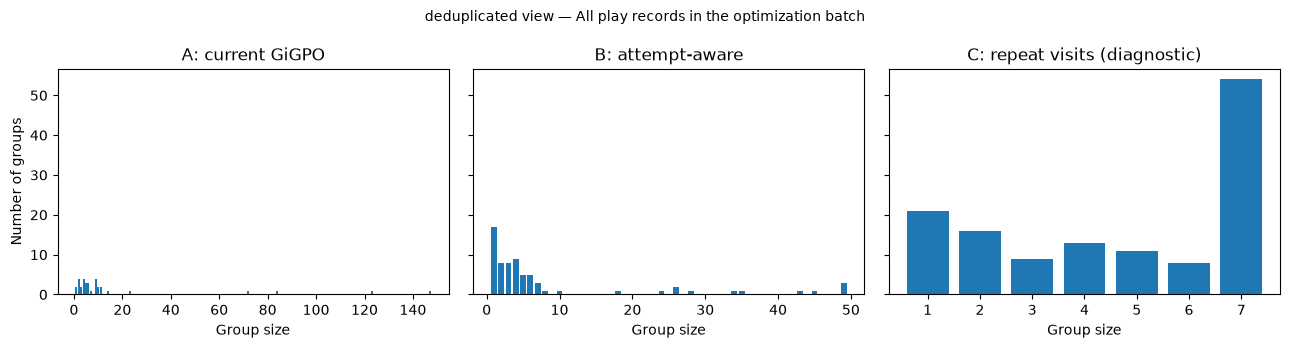

In [7]:
HISTOGRAM_VIEW = "deduplicated"
histogram_counts = {
    scheme: table["group_size"].value_counts().sort_index()
    for scheme, table in group_tables[HISTOGRAM_VIEW].items()
}
histogram_table = pd.DataFrame(histogram_counts).fillna(0).astype(int).sort_index()
histogram_table.index.name = "group_size"
display(histogram_table)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, (scheme, counts) in zip(axes, histogram_counts.items()):
    ax.bar(counts.index, counts.values, width=0.8)
    titles = {"A": "A: current GiGPO", "B": "B: attempt-aware", "C": "C: repeat visits (diagnostic)"}
    ax.set(title=titles[scheme], xlabel="Group size")
axes[0].set_ylabel("Number of groups")
fig.suptitle(f"{HISTOGRAM_VIEW} view — {COVERAGE}", fontsize=10)
fig.tight_layout()
plt.show()


## Largest groups under each grouping

Indices are stable within each `(view, scheme)` table. Use the displayed index,
view, and scheme in the manual helper below.


In [8]:
LARGEST_GROUPS_VIEW = "deduplicated"
for scheme, table in group_tables[LARGEST_GROUPS_VIEW].items():
    print(f"\nLargest {scheme} groups — {LARGEST_GROUPS_VIEW}")
    columns = ["uid", "group_size", "distinct_trajectory_count", "attempt_counts",
               "attempt", "trajectory", "step_return_min", "step_return_mean", "step_return_max"]
    with pd.option_context("display.max_columns", None, "display.max_colwidth", 60):
        display(table.sort_values("group_size", ascending=False, kind="stable")[columns].head(10))



Largest A groups — deduplicated


,uid,group_size,distinct_trajectory_count,attempt_counts,attempt,trajectory,step_return_min,step_return_mean,step_return_max
group_index,,,,,,,,,
26,3ffcc3c3-5ce3-4e67-ba36-7f13767e2a67,147,7,"{'1': 49, '2': 49, '3': 49}",None,None,-9.867898,-6.162733,-1.000000
28,fadb8d78-922a-4abb-8d6a-6329c3e5d6b7,123,7,"{'1': 35, '2': 45, '3': 43}",None,None,-9.867898,-5.606229,-0.100000
0,8b9e472d-b629-435a-a6d6-2c6bfd029849,84,6,"{'1': 24, '2': 26, '3': 34}",None,None,-9.867898,-5.490968,-1.000000
16,7406b6fd-a971-42fa-a1e3-961c7441d594,72,5,"{'1': 26, '2': 18, '3': 28}",None,None,-9.867898,-5.420998,-0.100000
30,fadb8d78-922a-4abb-8d6a-6329c3e5d6b7,23,2,"{'1': 10, '2': 6, '3': 7}",None,None,-7.502134,-4.434816,0.147500
15,7406b6fd-a971-42fa-a1e3-961c7441d594,14,2,"{'1': 6, '2': 8}",None,None,-6.355115,-4.063910,-1.474795
12,7406b6fd-a971-42fa-a1e3-961c7441d594,11,1,"{'1': 7, '2': 1, '3': 3}",None,None,-8.942971,-6.129441,-3.024381
14,7406b6fd-a971-42fa-a1e3-961c7441d594,11,2,"{'1': 3, '2': 3, '3': 5}",None,None,-6.260492,-3.307349,-0.709875
6,8b9e472d-b629-435a-a6d6-2c6bfd029849,10,1,"{'2': 4, '3': 6}",None,None,-5.453737,-3.639301,-1.000000



Largest B groups — deduplicated


,uid,group_size,distinct_trajectory_count,attempt_counts,attempt,trajectory,step_return_min,step_return_mean,step_return_max
group_index,,,,,,,,,
50,3ffcc3c3-5ce3-4e67-ba36-7f13767e2a67,49,7,{'1': 49},1,None,-9.867898,-8.120136,-6.216551
51,3ffcc3c3-5ce3-4e67-ba36-7f13767e2a67,49,7,{'2': 49},2,None,-8.694252,-6.744038,-4.619953
52,3ffcc3c3-5ce3-4e67-ba36-7f13767e2a67,49,7,{'3': 49},3,None,-6.033254,-3.624025,-1.000000
57,fadb8d78-922a-4abb-8d6a-6329c3e5d6b7,45,7,{'2': 45},2,None,-8.694252,-6.153597,-2.253841
58,fadb8d78-922a-4abb-8d6a-6329c3e5d6b7,43,7,{'3': 43},3,None,-6.033254,-3.357150,-0.100000
56,fadb8d78-922a-4abb-8d6a-6329c3e5d6b7,35,6,{'1': 35},1,None,-9.867898,-7.665626,-4.143880
2,8b9e472d-b629-435a-a6d6-2c6bfd029849,34,5,{'3': 34},3,None,-6.033254,-3.553165,-1.000000
35,7406b6fd-a971-42fa-a1e3-961c7441d594,28,5,{'3': 28},3,None,-6.033254,-3.145732,-0.100000
1,8b9e472d-b629-435a-a6d6-2c6bfd029849,26,5,{'2': 26},2,None,-8.694252,-6.088812,-1.060000



Largest C groups — deduplicated


,uid,group_size,distinct_trajectory_count,attempt_counts,attempt,trajectory,step_return_min,step_return_mean,step_return_max
group_index,,,,,,,,,
0,8b9e472d-b629-435a-a6d6-2c6bfd029849,7,1,{'1': 7},1,cf10f05d-86d6-4035-b368-51bfc0f925a5,-9.867898,-8.120136,-6.216551
1,8b9e472d-b629-435a-a6d6-2c6bfd029849,7,1,{'2': 7},2,cf10f05d-86d6-4035-b368-51bfc0f925a5,-8.694252,-6.744038,-4.619953
2,8b9e472d-b629-435a-a6d6-2c6bfd029849,7,1,{'3': 7},3,cf10f05d-86d6-4035-b368-51bfc0f925a5,-6.033254,-3.624025,-1.000000
5,8b9e472d-b629-435a-a6d6-2c6bfd029849,7,1,{'3': 7},3,01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0,-6.033254,-3.624025,-1.000000
7,8b9e472d-b629-435a-a6d6-2c6bfd029849,7,1,{'1': 7},1,899f9ea8-0684-402c-89d4-bcb97ce4ac8f,-9.329035,-7.488320,-5.483495
9,8b9e472d-b629-435a-a6d6-2c6bfd029849,7,1,{'3': 7},3,899f9ea8-0684-402c-89d4-bcb97ce4ac8f,-6.033254,-3.624025,-1.000000
11,8b9e472d-b629-435a-a6d6-2c6bfd029849,7,1,{'1': 7},1,0d8c3aac-fdce-4111-8423-0554e8b4abe0,-9.867898,-8.120136,-6.216551
12,8b9e472d-b629-435a-a6d6-2c6bfd029849,7,1,{'2': 7},2,0d8c3aac-fdce-4111-8423-0554e8b4abe0,-8.694252,-6.744038,-4.619953
13,8b9e472d-b629-435a-a6d6-2c6bfd029849,7,1,{'3': 7},3,0d8c3aac-fdce-4111-8423-0554e8b4abe0,-6.033254,-3.624025,-1.000000


## Three sources of multiplicity in A (deduplicated)

For an A group, let `n` be its visits, `a` its distinct attempts, and `p` its
trajectory/attempt pairs. Its size partitions exactly as:

`n = 1 + (a - 1) + (p - a) + (n - p)`

The three extra-count columns correspond to additional attempt memberships,
additional trajectories within an attempt, and repeated visits within a
trajectory/attempt. This is a count decomposition, not causal attribution.


In [9]:
multiplicity_rows = []
for group_index, group in group_tables["deduplicated"]["A"].iterrows():
    members = deduplicated_records.loc[group["_row_indices"]]
    n = len(members)
    a = members["traj_idx"].nunique()
    p = len(members[["traj_idx", "traj_uid"]].drop_duplicates())
    multiplicity_rows.append({
        "group_index": group_index, "uid": group["uid"], "visits": n,
        "attempts": a, "trajectory_attempt_pairs": p,
        "extra_attempt_memberships": a - 1,
        "extra_parallel_trajectory_memberships": p - a,
        "extra_same_trajectory_attempt_visits": n - p,
    })
multiplicity_df = pd.DataFrame(multiplicity_rows, columns=[
    "group_index", "uid", "visits", "attempts", "trajectory_attempt_pairs",
    "extra_attempt_memberships", "extra_parallel_trajectory_memberships",
    "extra_same_trajectory_attempt_visits",
]).set_index("group_index")
display(multiplicity_df.sort_values("visits", ascending=False).head(15))


,uid,visits,attempts,trajectory_attempt_pairs,extra_attempt_memberships,extra_parallel_trajectory_memberships,extra_same_trajectory_attempt_visits
group_index,,,,,,,
26,3ffcc3c3-5ce3-4e67-ba36-7f13767e2a67,147,3,21,2,18,126
28,fadb8d78-922a-4abb-8d6a-6329c3e5d6b7,123,3,20,2,17,103
0,8b9e472d-b629-435a-a6d6-2c6bfd029849,84,3,14,2,11,70
16,7406b6fd-a971-42fa-a1e3-961c7441d594,72,3,12,2,9,60
30,fadb8d78-922a-4abb-8d6a-6329c3e5d6b7,23,3,5,2,2,18
15,7406b6fd-a971-42fa-a1e3-961c7441d594,14,2,4,1,2,10
14,7406b6fd-a971-42fa-a1e3-961c7441d594,11,3,6,2,3,5
12,7406b6fd-a971-42fa-a1e3-961c7441d594,11,3,3,2,0,8
6,8b9e472d-b629-435a-a6d6-2c6bfd029849,10,2,2,1,0,8


## Repeated-state groups under C

A deduplicated C group of size greater than one proves repeated **pre-action**
board visits in one trajectory/attempt. Its last action may change the board.
Only compare `anchor_obs` with the stored **post-action** `next_anchor_obs` to
classify an action as leaving the visible board unchanged. Revisits need not be
consecutive.

`is_action_valid` means **parser success**, not legal bounds or environment
success. `action_is_effective` is the environment's own flag, retained verbatim.
It compares `board_disp` with `board_disp_prev`; early-return branches can leave
that previous-board buffer stale. We therefore keep this flag separate from the
observed board comparison. There is no separate environment-validity/no-op flag,
and we do not infer one from the reward.


In [10]:
def board_unchanged(row):
    next_board = row["next_anchor_obs"]
    return row["anchor_obs"] == next_board if isinstance(next_board, str) else pd.NA

for records_df in record_views.values():
    records_df["observed_board_unchanged"] = records_df.apply(board_unchanged, axis=1).astype("boolean") if len(records_df) else pd.Series(dtype="boolean")

repeated_c_groups = group_tables["deduplicated"]["C"].loc[
    group_tables["deduplicated"]["C"]["group_size"].gt(1)
]
repeated_rows = []
for group_index, group in repeated_c_groups.iterrows():
    members = deduplicated_records.loc[group["_row_indices"]].sort_values("turn_idx")
    repeated_rows.append({
        "group_index": group_index, "uid": group["uid"], "trajectory": group["trajectory"],
        "attempt": group["attempt"], "group_size": group["group_size"],
        "turn_indices": members["turn_idx"].tolist(), "actions": members["parsed_action"].tolist(),
        "parsing_validity": members["is_action_valid"].tolist(),
        "environment_effectiveness": members["action_is_effective"].tolist(),
        "observed_board_unchanged": members["observed_board_unchanged"].tolist(),
        "immediate_rewards": members["immediate_reward"].tolist(),
        "step_returns": members["step_return"].tolist(),
    })
repeated_state_df = pd.DataFrame(repeated_rows, columns=[
    "group_index", "uid", "trajectory", "attempt", "group_size", "turn_indices", "actions",
    "parsing_validity", "environment_effectiveness", "observed_board_unchanged",
    "immediate_rewards", "step_returns",
]).set_index("group_index").sort_values("group_size", ascending=False, kind="stable")
with pd.option_context("display.max_columns", None, "display.max_colwidth", 100):
    display(repeated_state_df)


,uid,trajectory,attempt,group_size,turn_indices,actions,parsing_validity,environment_effectiveness,observed_board_unchanged,immediate_rewards,step_returns
group_index,,,,,,,,,,,
0,8b9e472d-b629-435a-a6d6-2c6bfd029849,cf10f05d-86d6-4035-b368-51bfc0f925a5,1,7,"[0, 1, 2, 3, 4, 5, 6]","[[-1, -1], [-1, -1], [-1, -1], [2, 1], [-1, -1], [-1, -1], [-1, -1]]","[False, False, False, True, False, False, False]","[False, False, False, False, False, False, False]","[True, True, True, True, True, True, True]","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0]","[-9.867897987365723, -9.334630012512207, -8.773294448852539, -8.182415008544922, -7.560437202453..."
1,8b9e472d-b629-435a-a6d6-2c6bfd029849,cf10f05d-86d6-4035-b368-51bfc0f925a5,2,7,"[0, 1, 2, 3, 4, 5, 6]","[[2, 3], [-1, -1], [-1, -1], [-1, -1], [-1, -1], [-1, -1], [-1, -1]]","[True, False, False, False, False, False, False]","[False, False, False, False, False, False, False]","[True, True, True, True, True, True, True]","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0]","[-8.694252014160156, -8.099212646484375, -7.472855091094971, -6.813531875610352, -6.119507312774..."
2,8b9e472d-b629-435a-a6d6-2c6bfd029849,cf10f05d-86d6-4035-b368-51bfc0f925a5,3,7,"[0, 1, 2, 3, 4, 5, 6]","[[-1, -1], [-1, -1], [-1, -1], [-1, -1], [-1, -1], [2, 3], [-1, -1]]","[False, False, False, False, False, True, False]","[False, False, False, False, False, False, False]","[True, True, True, True, True, True, True]","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0]","[-6.033254146575928, -5.29816198348999, -4.524381160736084, -3.7098751068115234, -2.852499961853..."
5,8b9e472d-b629-435a-a6d6-2c6bfd029849,01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0,3,7,"[0, 1, 2, 3, 4, 5, 6]","[[-1, -1], [-1, -1], [-1, -1], [-1, -1], [2, 1], [-1, -1], [-1, -1]]","[False, False, False, False, True, False, False]","[False, False, False, False, False, False, False]","[True, True, True, True, True, True, True]","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0]","[-6.033254146575928, -5.29816198348999, -4.524381160736084, -3.7098751068115234, -2.852499961853..."
7,8b9e472d-b629-435a-a6d6-2c6bfd029849,899f9ea8-0684-402c-89d4-bcb97ce4ac8f,1,7,"[0, 1, 2, 3, 4, 5, 6]","[[-1, -1], [2, 3], [-1, -1], [-1, -1], [-1, -1], [-1, -1], [-1, -1]]","[False, True, False, False, False, False, False]","[False, False, False, False, False, False, False]","[True, True, True, True, True, True, True]","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0]","[-9.329034805297852, -8.76740550994873, -8.176216125488281, -7.5539116859436035, -6.898854732513..."
...,...,...,...,...,...,...,...,...,...,...,...
74,7406b6fd-a971-42fa-a1e3-961c7441d594,083abec7-5b39-4f52-add8-68d15a11b295,3,2,"[5, 6]","[[-1, -1], [-1, -1]]","[False, False]","[True, True]","[True, True]","[-1.0, -1.0]","[-1.9500000476837158, -1.0]"
110,fadb8d78-922a-4abb-8d6a-6329c3e5d6b7,f1748a53-df3b-4a44-bddf-914b907d4cbc,3,2,"[5, 6]","[[4, 2], [-1, -1]]","[True, False]","[True, True]","[True, True]","[-1.0, -1.0]","[-1.9500000476837158, -1.0]"
117,fadb8d78-922a-4abb-8d6a-6329c3e5d6b7,dfca3b84-4d60-4284-b346-e6209fe88278,1,2,"[0, 1]","[[-1, -1], [4, 1]]","[False, True]","[False, True]","[True, False]","[-1.0, -0.1]","[-4.936685562133789, -4.1438798904418945]"


## Classify observed unchanged-board transitions

Counts below use deduplicated records in repeated C groups. Missing metadata is
unknown, not false. The parser and environment categories **overlap**: an action
may fail parsing and also be environment-reported ineffective. “Parsing-valid,
board unchanged” does not establish that the action was legal or successful.

For old captures, structural revisits are measurable, but action/transition
attribution remains unavailable. Capture again to obtain the new metadata.


In [11]:
repeated_indices = [i for indices in repeated_c_groups["_row_indices"] for i in indices]
repeated_records = deduplicated_records.loc[repeated_indices]
unchanged_mask = repeated_records["observed_board_unchanged"].fillna(False)
unchanged_records = repeated_records.loc[unchanged_mask]
transition_counts = pd.Series({
    "Repeated C groups": len(repeated_c_groups),
    "Visits in repeated C groups": len(repeated_records),
    "Observed unchanged-board transitions": len(unchanged_records),
    "Unchanged + parsing-invalid": int(unchanged_records["is_action_valid"].eq(False).sum()),
    "Unchanged + environment-reported ineffective (overlaps)": int(unchanged_records["action_is_effective"].eq(False).sum()),
    "Unchanged + parsing-valid (not environment-validity)": int(unchanged_records["is_action_valid"].eq(True).sum()),
    "Unchanged + parsing validity unavailable": int(unchanged_records["is_action_valid"].isna().sum()),
    "Unchanged + environment flag says effective": int(unchanged_records["action_is_effective"].eq(True).sum()),
    "Visits with post-action board unavailable": int(repeated_records["observed_board_unchanged"].isna().sum()),
    "Visits whose action changed the visible board": int(repeated_records["observed_board_unchanged"].eq(False).sum()),
}, name="count")
display(transition_counts.to_frame())


,count
Repeated C groups,111
Visits in repeated C groups,592
Observed unchanged-board transitions,559
Unchanged + parsing-invalid,501
Unchanged + environment-reported ineffective (overlaps),439
Unchanged + parsing-valid (not environment-validity),58
Unchanged + parsing validity unavailable,0
Unchanged + environment flag says effective,120
Visits with post-action board unavailable,0
Visits whose action changed the visible board,33


## Inspect one group in full

Choose a view (`optimization` or `deduplicated`), scheme (`A`, `B`, or `C`), and
index from the corresponding group table. The helper retains every member in
that selected view, prints all reflection text, and displays each action's flags,
reward, and return.

For **optimization A**, `mean(step_return)` is the current GiGPO step baseline;
`step_return - mean` is its step component in published `mean_norm` mode.
Deduplicated A and B/C baselines are **hypothetical diagnostic comparisons**.
They are never used for training. None of these displays is the final PPO
advantage: episode advantage, step weight, and token mask are excluded. Float64
analysis may differ slightly from tensor calculations due to rounding.


In [12]:
def inspect_group(group_index, scheme="A", view="optimization"):
    table = group_tables[view][scheme]
    if group_index not in table.index:
        raise KeyError(f"Unknown index {group_index} for {view}/{scheme}.")
    group = table.loc[group_index]
    members = record_views[view].loc[group["_row_indices"]].copy()
    members = members.sort_values(["traj_uid", "traj_idx", "turn_idx"], kind="stable")
    baseline = members["step_return"].mean()
    members["mean_normalized_step_advantage"] = members["step_return"] - baseline
    actual = view == "optimization" and scheme == "A"
    print(f"GROUP {group_index} — scheme {scheme}, view {view}")
    print("Coverage:", COVERAGE)
    print("Actual GiGPO step baseline" if actual else "HYPOTHETICAL diagnostic baseline — NOT training")
    print(f"Mean step return: {baseline:.10f}")
    print("uid:", group["uid"], "| group size:", group["group_size"])
    print("Trajectories:", group["distinct_trajectory_count"], "| attempt counts:", group["attempt_counts"])
    print("\nFull anchor_obs board:\n" + group["anchor_obs"])
    columns = ["traj_uid", "traj_idx", "turn_idx", "parsed_action", "is_action_valid",
               "action_is_effective", "observed_board_unchanged", "immediate_reward",
               "step_return", "mean_normalized_step_advantage"]
    with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None):
        display(members[columns])
    for record_index, member in members.iterrows():
        print(f"\nRecord {record_index}: trajectory={member['traj_uid']}, "
              f"attempt={member['traj_idx']}, turn={member['turn_idx']}")
        print("Action:", member["parsed_action"], "| parsing validity:", member["is_action_valid"],
              "| immediate reward:", member["immediate_reward"], "| step return:", member["step_return"])
        reflections = member["previous_reflections"]
        if not reflections:
            print("previous_reflections: []")
        for reflection_index, reflection in enumerate(reflections, start=1):
            print(f"Previous reflection entry {reflection_index}:")
            print(reflection if reflection else '[empty string: ""]')
    return members


In [13]:
SELECTED_VIEW = "optimization"  # or "deduplicated"
SELECTED_SCHEME = "A"          # A, B, or C
SELECTED_GROUP_INDEX = 0
if not group_tables[SELECTED_VIEW][SELECTED_SCHEME].empty:
    selected_members_df = inspect_group(SELECTED_GROUP_INDEX, SELECTED_SCHEME, SELECTED_VIEW)
else:
    print("No group is available in the selected view.")
# To inspect a repeated-state group:
# inspect_group(repeated_state_df.index[0], scheme="C", view="deduplicated")


GROUP 0 — scheme A, view optimization
Coverage: All play records in the optimization batch
Actual GiGPO step baseline
Mean step return: -5.6174359189
uid: 8b9e472d-b629-435a-a6d6-2c6bfd029849 | group size: 108
Trajectories: 6 | attempt counts: {'1': 34, '2': 33, '3': 41}

Full anchor_obs board:
Row 1: . . . . . .
Row 2: 1 1 1 . . .
Row 3: ? ? 1 . . .
Row 4: ? ? 2 . . .
Row 5: ? ? 2 . . .
Row 6: ? ? 2 . . .


,traj_uid,traj_idx,turn_idx,parsed_action,is_action_valid,action_is_effective,observed_board_unchanged,immediate_reward,step_return,mean_normalized_step_advantage
21,01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0,1,0,"[-1, -1]",False,False,True,-1.0,-6.086605,-0.469169
105,01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0,1,0,"[-1, -1]",False,False,True,-1.0,-6.086605,-0.469169
22,01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0,1,1,"[-1, -1]",False,False,True,-1.0,-5.354321,0.263115
106,01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0,1,1,"[-1, -1]",False,False,True,-1.0,-5.354321,0.263115
23,01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0,1,2,"[3, 2]",True,True,False,-0.1,-4.583496,1.033940
107,01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0,1,2,"[3, 2]",True,True,False,-0.1,-4.583496,1.033940
24,01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0,2,0,"[-1, -1]",False,False,True,-1.0,-7.472492,-1.855056
25,01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0,2,1,"[-1, -1]",False,False,True,-1.0,-6.813150,-1.195714
26,01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0,2,2,"[-1, -1]",False,False,True,-1.0,-6.119105,-0.501669
27,01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0,2,3,"[-1, -1]",False,False,True,-1.0,-5.388532,0.228904



Record 21: trajectory=01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0, attempt=1, turn=0
Action: [-1, -1] | parsing validity: False | immediate reward: -1.0 | step return: -6.086604595184326
previous_reflections: []

Record 105: trajectory=01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0, attempt=1, turn=0
Action: [-1, -1] | parsing validity: False | immediate reward: -1.0 | step return: -6.086604595184326
previous_reflections: []

Record 22: trajectory=01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0, attempt=1, turn=1
Action: [-1, -1] | parsing validity: False | immediate reward: -1.0 | step return: -5.354320526123047
previous_reflections: []

Record 106: trajectory=01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0, attempt=1, turn=1
Action: [-1, -1] | parsing validity: False | immediate reward: -1.0 | step return: -5.354320526123047
previous_reflections: []

Record 23: trajectory=01f4cd6b-97a6-4076-a7cd-36b5dcef8ec0, attempt=1, turn=2
Action: ['3', '2'] | parsing validity: True | immediate reward: -0.1 | step return: -4.58349561